# Phase 7 — Model 1: Financial Inclusion

This notebook reproduces training, model selection, and protected-holdout evaluation for `account_fin` only. Identical predictor profiles remain grouped across every split. Model 2 and SHAP explainability are intentionally outside this phase.

In [1]:
from pathlib import Path
import os
import sys

os.environ.setdefault('OPENBLAS_NUM_THREADS', '1')
os.environ.setdefault('MPLBACKEND', 'Agg')
project_root = next(path for path in (Path.cwd(), *Path.cwd().parents) if (path / 'pyproject.toml').is_file())
sys.path.insert(0, str(project_root / 'src'))

import matplotlib.image as mpimg
import matplotlib.pyplot as plt
import pandas as pd
from IPython.display import display
from finaccess_eswatini.phase7_model1 import run

summary = run()
report_dir = project_root / 'reports' / 'phase_7'
print('Selected model:', summary['selection']['selected_model_label'])
print('Protected holdout rows:', summary['split']['test_rows'])
print('Profile overlap across holdout:', summary['split']['profile_overlap_count'])
print('Model 2 trained:', summary['model2_trained'])

Selected model: Gradient Boosting
Protected holdout rows: 211
Profile overlap across holdout: 0
Model 2 trained: False


## Training-fold model comparison

All candidates use the same group-aware cross-validation folds. The protected holdout is not used in this table or in model selection.

,model,parameter_combinations,cv_mean_roc_auc,cv_std_roc_auc,cv_mean_accuracy,cv_mean_precision,cv_mean_recall,cv_mean_f1,cv_mean_brier,train_cv_roc_auc_gap,within_one_se_of_best_auc,selected
4,Gradient Boosting,16,0.7683,0.0240,0.6976,0.7014,0.7134,0.7052,0.1975,0.0448,True,True
3,Random Forest,12,0.7590,0.0220,0.6785,0.6888,0.6784,0.6822,0.2022,0.0986,True,False
1,Logistic Regression,6,0.7564,0.0226,0.6882,0.6983,0.6855,0.6894,0.2017,0.0313,False,False
2,Decision Tree,18,0.7058,0.0325,0.6309,0.6406,0.6387,0.6369,0.2234,0.0547,False,False
0,Dummy majority baseline,1,0.5000,0.0000,0.5107,0.5107,1.0000,0.6761,0.2499,0.0000,False,False


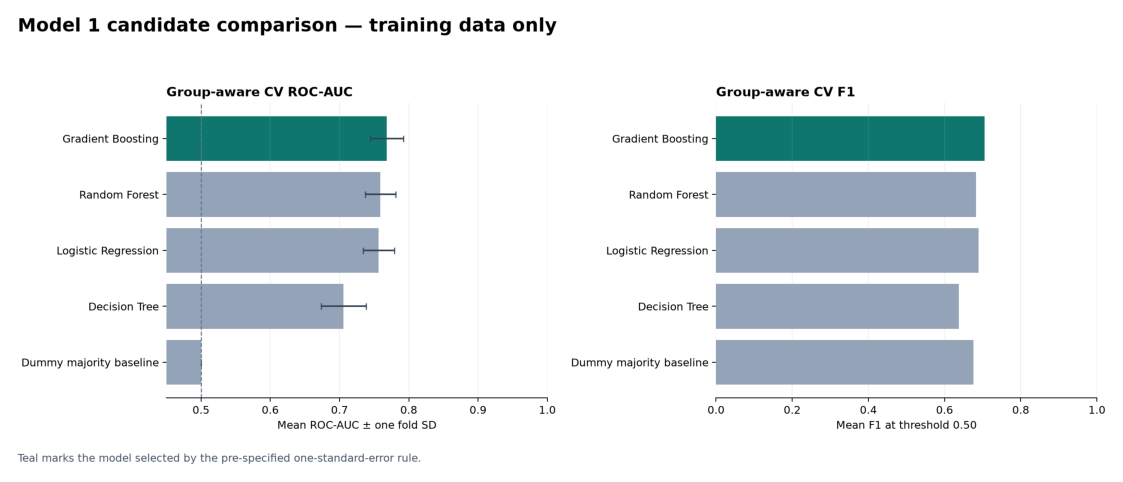

In [2]:
comparison = pd.read_csv(report_dir / 'model_comparison.csv')
comparison_view = comparison[[
    'model', 'parameter_combinations', 'cv_mean_roc_auc', 'cv_std_roc_auc',
    'cv_mean_accuracy', 'cv_mean_precision', 'cv_mean_recall', 'cv_mean_f1',
    'cv_mean_brier', 'train_cv_roc_auc_gap', 'within_one_se_of_best_auc', 'selected'
]].copy()
numeric = comparison_view.select_dtypes('number').columns
comparison_view[numeric] = comparison_view[numeric].round(4)
display(comparison_view.sort_values('cv_mean_roc_auc', ascending=False))

image = mpimg.imread(report_dir / 'figures' / '01_model_comparison.png')
plt.figure(figsize=(15, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## Protected-holdout evaluation

Only the selected pipeline is evaluated here. Bootstrap intervals communicate the uncertainty from the 211-row holdout. The 0.50 classification threshold is provisional and was not tuned on this test set.

,metric,value,lower_95,upper_95
0,accuracy,0.7062,0.6445,0.7630
1,balanced_accuracy,0.7062,NaN,NaN
2,precision,0.7170,0.6535,0.7813
3,recall,0.7037,0.6201,0.7870
4,f1,0.7103,0.6422,0.7706
5,roc_auc,0.7449,0.6737,0.8052
6,brier_score,0.2042,0.1822,0.2288
7,log_loss,0.5942,NaN,NaN


predicted,0,1
actual,,
0,73,30
1,32,76


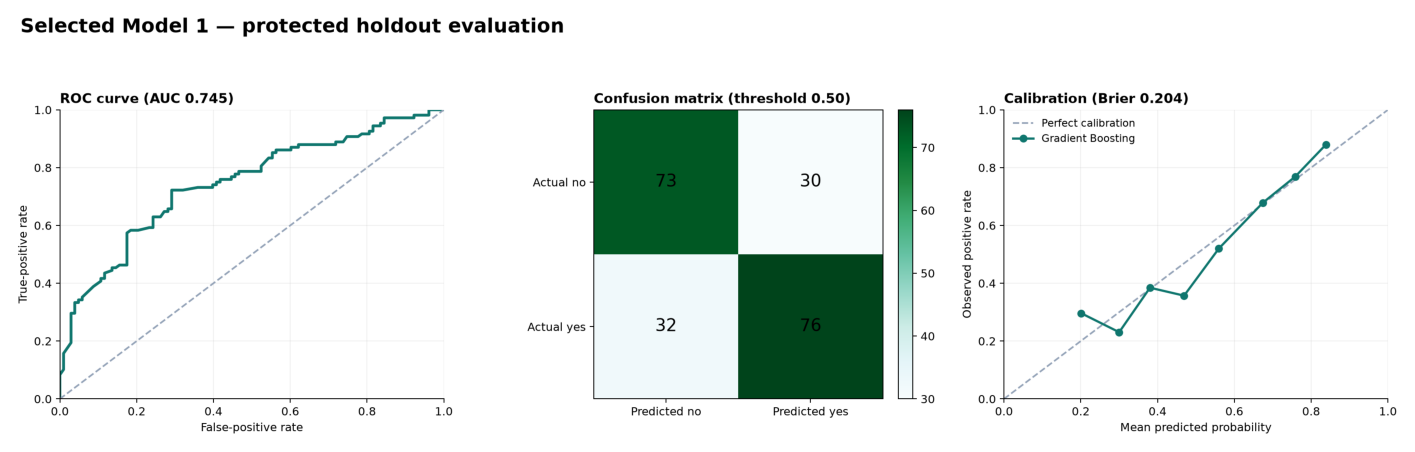

In [3]:
metrics = pd.read_csv(report_dir / 'holdout_metrics.csv')
intervals = pd.read_csv(report_dir / 'bootstrap_intervals.csv')
results = metrics.merge(intervals[['metric', 'lower_95', 'upper_95']], on='metric', how='left')
display(results.round(4))

confusion = pd.read_csv(report_dir / 'confusion_matrix.csv')
display(confusion.pivot(index='actual', columns='predicted', values='count'))

image = mpimg.imread(report_dir / 'figures' / '02_holdout_evaluation.png')
plt.figure(figsize=(18, 6))
plt.imshow(image)
plt.axis('off')
plt.show()

## Generalisation guardrails

Performance describes prediction in the supplied observational sample, not causation or production readiness. Feature importance and individual explanations are reserved for Phase 9.

In [4]:
print('Train–CV AUC gap:', round(summary['diagnostics']['train_cv_auc_gap'], 4))
print('Holdout minus CV AUC:', round(summary['diagnostics']['holdout_minus_cv_auc'], 4))
print('Expected calibration error:', round(summary['diagnostics']['expected_calibration_error'], 4))
print('Unseen holdout categories:', summary['diagnostics']['unseen_holdout_category_count'])
print('\nImportant limitations:')
for limitation in summary['limitations']:
    print(f'• {limitation}')

Train–CV AUC gap: 0.0448
Holdout minus CV AUC: -0.0235
Expected calibration error: 0.0475
Unseen holdout categories: 1

Important limitations:
• small protected holdout produces material metric uncertainty
• 134 respondents belong to identical predictor profiles with conflicting outcomes
• fixed age bands lose within-band information
• observational predictors do not support causal claims
• 0.50 threshold remains provisional
• survey weights were not used as predictors or loss weights
